### Imports and Setup

In [1]:
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, precision_recall_curve

from whale_gunshot_localization.models.tcn_archs import TCNClassifier
from whale_gunshot_localization.datasets.dataloaders import get_dataloaders_classify, get_exp_data_dataloader_classify
from whale_gunshot_localization.utils.transformations import get_image_transform_classify, to_spect

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
from whale_gunshot_localization import config

Using the GPU!


Settings for synthetic data evaluation

In [3]:
split = 'test'

### Prepare For Evaluation
Get dataloaders

In [4]:
dl = get_dataloaders_classify(splits=['train', 'val', 'test'],
                              batch_size=128,
                              shuffle=False,
                              transform=get_image_transform_classify(),
                              squeeze=True,
                              num_workers=20)

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/data/TOSSIT_sims/mean_classification.npy'

Load the desired model

In [4]:
model = TCNClassifier(input_size=dl[split].dataset.size[0], 
                      num_channels=5*[250],
                      kernel_size=6,
                      dropout=0.05).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'] + '/classifier', 'weights_4.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

## Evaluate Model On Synthetic Data
Get predictions and labels

In [5]:
def evaluate_model(model, dataloader, thresh=0.5):
    """
    Get lists of targets and predictions using a provided model and dataloader.
    
    Parameters
    ----------
    model : nn.Module
        model to be evaluated
    dataloader : data.DataLoader
        dataloader to use in model evaluation
    
    Returns
    -------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    outputs_all : array-like
        all model outputs
    """
    # put model in evaluatio mode
    model.eval()
    
    # initialize arrays for results
    c_t, c_p, outputs_all = [], [], []
    
    for inputs, targets in tqdm(dataloader):
        
        # put data on device
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        with torch.set_grad_enabled(False):
            # get outputs and store
            outputs = model(inputs)
            
            outputs_all += outputs.detach().tolist()
            
            # store x predictions and labels
            c_p += (torch.sigmoid((outputs).detach()) >= thresh).float().tolist()
            c_t += (targets).detach().tolist()
    
    return np.asarray(c_p), np.asarray(c_t), np.asarray(outputs_all)

In [1]:
c_p, c_t, outputs_all = evaluate_model(model, dl[split])

acc = accuracy_score(c_t, c_p)
prec = precision_score(c_t, c_p)
recall = recall_score(c_t, c_p)
print(f'Accuracy: {np.around(acc, 5)}')
print(f'Precision: {np.around(prec, 5)}')
print(f'Recall: {np.around(recall, 5)}')

NameError: name 'evaluate_model' is not defined

In [15]:
precisions, recalls, thresholds = precision_recall_curve(c_t, outputs_all)

Text(0, 0.5, 'Precision')

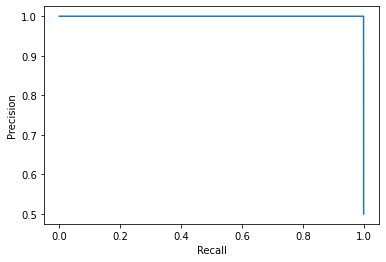

In [16]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")

## Evaluation Model On Experimental Data

get dataloaders

In [9]:
dl_exp = get_exp_data_dataloader_classify(batch_size=128, transform=get_image_transform_classify(), squeeze=True, TOSSIT=1)

get predictions and labels

In [10]:
c_p, c_t, outputs_all = evaluate_model(model, dl_exp)

  0%|          | 0/1 [00:00<?, ?it/s]